# Ensemble Learning: Random Forest vs XGBoost

## Step 1: Import Libraries

In this project, we will compare Random Forest and XGBoost ensemble models with our earlier Logistic Regression and Decision Tree models for customer churn prediction.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

## Step 2: Load Dataset

The Telco Customer Churn dataset used in the previous classification task is loaded for ensemble learning. Using the same dataset allows us to compare the new ensemble models with our earlier models.

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Step 3: Data Cleaning

The TotalCharges column is converted into numeric format and missing values are handled before training the models.

In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [6]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Step 4: Encode Categorical Variables

Machine learning models require numerical input, so categorical variables are converted into numerical values using one-hot encoding
.

In [9]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [10]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [11]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


## Step 5: Prepare Features and Target Variable

The dataset is divided into input features (X) and the target variable (y). The data is then split into training and testing sets so that the models can be trained and evaluated fairly.

In [14]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [16]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [17]:
print(X.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF', 'customerID_0013-SMEOE',
       ...
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str', length=7072)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 7072)
Testing data: (1409, 7072)


## Step 6: Train Logistic Regression

Logistic Regression is used as a baseline single machine learning model. Its performance will be compared with the ensemble models.

In [20]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:", logistic_accuracy * 100)

Logistic Regression Accuracy: 78.21149751596877


c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 7: Train Decision Tree

A Decision Tree classifier is trained as another single-model baseline. Its accuracy will be compared with the ensemble models.

In [21]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

tree_pred = decision_tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy * 100)

Decision Tree Accuracy: 77.21788502484031


## Step 8: Train Random Forest Classifier

Random Forest is an ensemble model that combines predictions from multiple decision trees. This usually makes the model more robust than using a single decision tree.

In [22]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy * 100)

Random Forest Accuracy: 79.91483321504613


## Step 9: Train XGBoost Classifier

XGBoost is an ensemble learning algorithm that builds decision trees sequentially. Each new tree focuses on improving the errors made by the previous trees.

In [23]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy * 100)

XGBoost Accuracy: 77.43080198722498


## Step 10: Model Performance Comparison

The performance of the two ensemble models is compared with the earlier single models using accuracy score.

In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy * 100,
        tree_accuracy * 100,
        rf_accuracy * 100,
        xgb_accuracy * 100
    ]
})

results

,Model,Accuracy
0,Logistic Regression,78.211498
1,Decision Tree,77.217885
2,Random Forest,79.914833
3,XGBoost,77.430802


## Step 11: Model Accuracy Comparison

A bar chart is used to visually compare the accuracy of all four models.

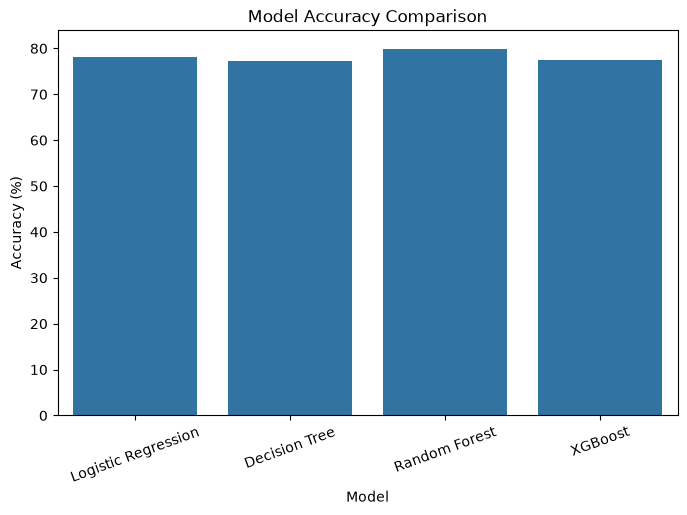

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)

plt.show()

## Step 12: Random Forest Feature Importance

Feature importance shows which features contributed most to the Random Forest model's predictions.

In [26]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(10)

,Feature,Importance
3,TotalCharges,0.101010
1,tenure,0.097907
2,MonthlyCharges,0.083143
7070,PaymentMethod_Electronic check,0.026117
7052,InternetService_Fiber optic,0.025539
7067,Contract_Two year,0.023923
7055,OnlineSecurity_Yes,0.021303
7061,TechSupport_Yes,0.019204
7068,PaperlessBilling_Yes,0.017406
7066,Contract_One year,0.016825


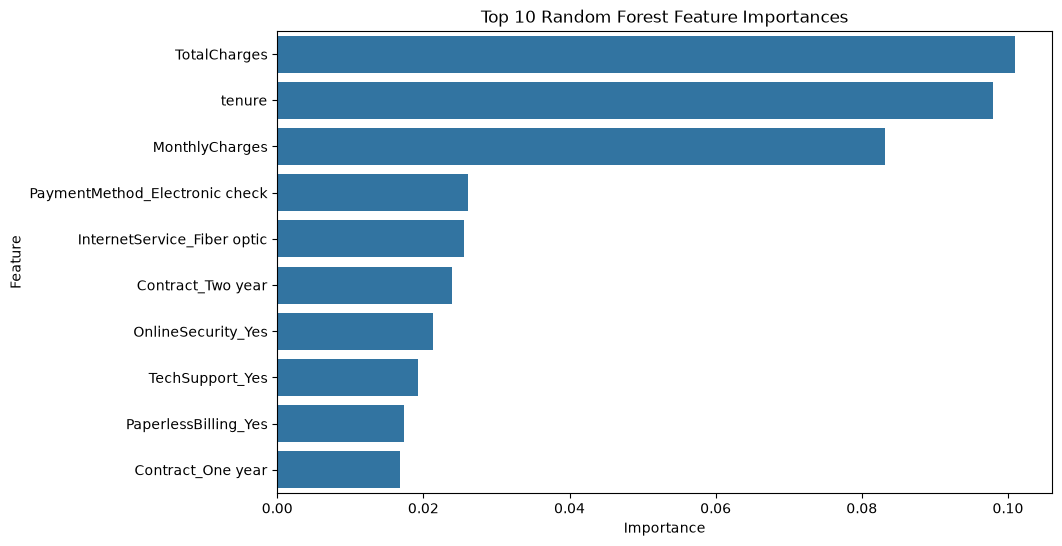

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance.head(10)
)

plt.title("Top 10 Random Forest Feature Importances")

plt.show()